<a href="https://www.kaggle.com/code/lalit7881/75-years-of-formula-1-a-data-driven-journey?scriptVersionId=314480249" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_constructor_standings.csv
/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_constructors.csv
/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_drivers.csv
/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_circuits.csv
/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_races.csv
/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_qualifying.csv
/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_results.csv
/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_driver_standings.csv


## Loading dataset

In [2]:
constructor_standings = pd.read_csv("/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_constructor_standings.csv")

constructors = pd.read_csv("/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_constructors.csv")

drivers = pd.read_csv("/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_drivers.csv")

circuits = pd.read_csv("/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_circuits.csv")

races = pd.read_csv("/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_races.csv")

qualifying = pd.read_csv("/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_qualifying.csv")

results = pd.read_csv("/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_results.csv")

driver_standings = pd.read_csv("/kaggle/input/datasets/patelris/formula-1-complete-dataset-1950-2026/f1_driver_standings.csv")

In [3]:
# Preview data
print(drivers.head())

# Dataset info
drivers.info()

# Summary statistics
drivers.describe()

# Check missing values
print(drivers.isnull().sum())

   driver_id given_name family_name         dob nationality  number code  \
0      abate      Carlo       Abate  1932-07-10     Italian     NaN  NaN   
1  abecassis     George   Abecassis  1913-03-21     British     NaN  NaN   
2    acheson      Kenny     Acheson  1957-11-27     British     NaN  NaN   
3      adams   Philippe       Adams  1969-11-19     Belgian     NaN  NaN   
4       ader       Walt        Ader  1913-12-15    American     NaN  NaN   

                                              url  
0  http://en.wikipedia.org/wiki/Carlo_Mario_Abate  
1   http://en.wikipedia.org/wiki/George_Abecassis  
2      http://en.wikipedia.org/wiki/Kenny_Acheson  
3     http://en.wikipedia.org/wiki/Philippe_Adams  
4          http://en.wikipedia.org/wiki/Walt_Ader  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 879 entries, 0 to 878
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   driver_id    879 non-null    object 
 

In [4]:
print(results.columns)
print(drivers.columns)
print(constructors.columns)
print(races.columns)

Index(['season', 'round', 'race_name', 'driver_id', 'driver_name',
       'constructor_id', 'constructor', 'grid', 'position', 'points', 'laps',
       'status', 'time', 'fastest_lap', 'fastest_lap_rank'],
      dtype='object')
Index(['driver_id', 'given_name', 'family_name', 'dob', 'nationality',
       'number', 'code', 'url'],
      dtype='object')
Index(['constructor_id', 'name', 'nationality', 'url'], dtype='object')
Index(['season', 'round', 'race_name', 'circuit_id', 'date', 'time', 'url'], dtype='object')


In [5]:
df = results.merge(drivers, on='driver_id', how='left') \
            .merge(constructors, on='constructor_id', how='left') \
            .merge(races, on=['season', 'round', 'race_name'], how='left')

In [6]:
df.columns


Index(['season', 'round', 'race_name', 'driver_id', 'driver_name',
       'constructor_id', 'constructor', 'grid', 'position', 'points', 'laps',
       'status', 'time_x', 'fastest_lap', 'fastest_lap_rank', 'given_name',
       'family_name', 'dob', 'nationality_x', 'number', 'code', 'url_x',
       'name', 'nationality_y', 'url_y', 'circuit_id', 'date', 'time_y',
       'url'],
      dtype='object')

In [7]:
df = df.rename(columns={
    'name': 'constructor_name',
    'nationality_x': 'driver_nationality',
    'nationality_y': 'constructor_nationality'
})

In [8]:
df['full_name'] = df['given_name'] + " " + df['family_name']

In [9]:
df = df[['season', 'round', 'race_name', 'date',
         'full_name', 'driver_nationality',
         'constructor_name', 'constructor_nationality',
         'grid', 'position', 'points', 'laps']]

In [10]:
print(df.head())
print(df.shape)

   season  round           race_name        date       full_name  \
0    1950      1  British Grand Prix  1950-05-13     Nino Farina   
1    1950      1  British Grand Prix  1950-05-13   Luigi Fagioli   
2    1950      1  British Grand Prix  1950-05-13     Reg Parnell   
3    1950      1  British Grand Prix  1950-05-13  Yves Cabantous   
4    1950      1  British Grand Prix  1950-05-13    Louis Rosier   

  driver_nationality constructor_name constructor_nationality  grid  position  \
0            Italian       Alfa Romeo                   Swiss     1         1   
1            Italian       Alfa Romeo                   Swiss     2         2   
2            British       Alfa Romeo                   Swiss     4         3   
3             French      Talbot-Lago                  French     6         4   
4             French      Talbot-Lago                  French     9         5   

   points  laps  
0     9.0    70  
1     6.0    70  
2     4.0    70  
3     3.0    68  
4     2.0    6

In [11]:
df[df['position'] == 1]['full_name'].value_counts().head(10)

full_name
Lewis Hamilton        105
Michael Schumacher     91
Max Verstappen         71
Sebastian Vettel       53
Alain Prost            51
Ayrton Senna           41
Fernando Alonso        32
Nigel Mansell          31
Jackie Stewart         27
Jim Clark              25
Name: count, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

sns.set_style("darkgrid")

In [13]:
# Merge
df = results.merge(drivers, on='driver_id', how='left') \
            .merge(constructors, on='constructor_id', how='left') \
            .merge(races, on=['season', 'round', 'race_name'], how='left')

# Feature engineering
df['driver_name'] = df['given_name'] + " " + df['family_name']
df['date'] = pd.to_datetime(df['date'])

## EDA

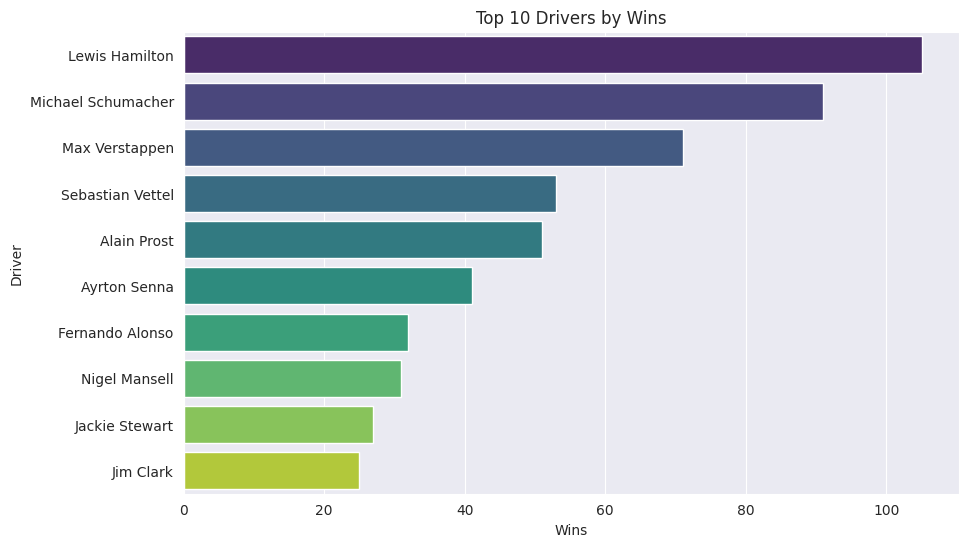

In [14]:
top_drivers = df[df['position'] == 1]['driver_name'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_drivers.values, y=top_drivers.index, palette="viridis")
plt.title("Top 10 Drivers by Wins")
plt.xlabel("Wins")
plt.ylabel("Driver")
plt.show()

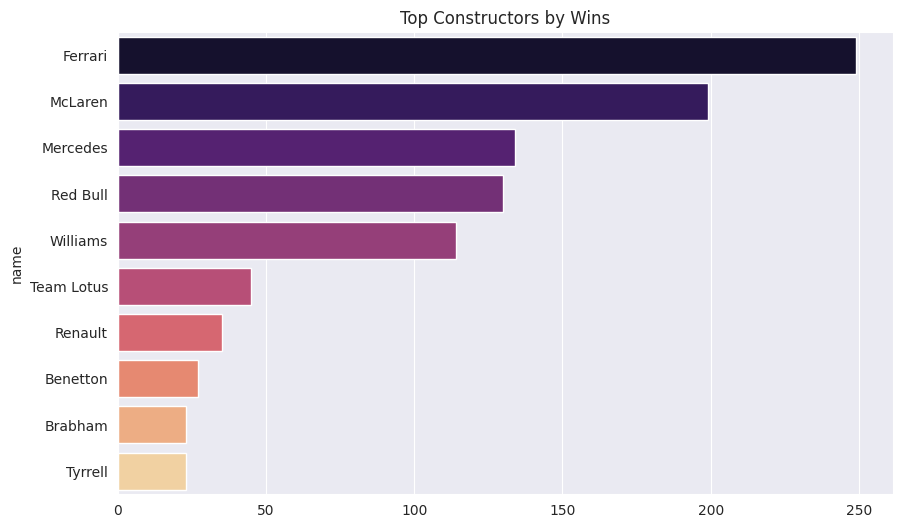

In [15]:
top_const = df[df['position'] == 1]['name'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_const.values, y=top_const.index, palette="magma")
plt.title("Top Constructors by Wins")
plt.show()

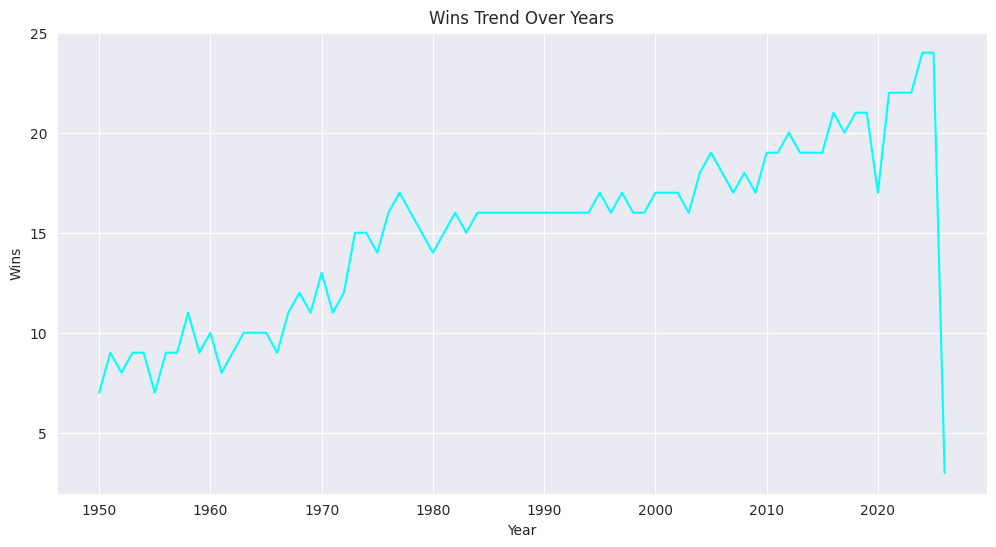

In [16]:
wins_year = df[df['position'] == 1].groupby('season').size()

plt.figure(figsize=(12,6))
wins_year.plot(color='cyan')
plt.title("Wins Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Wins")
plt.show()

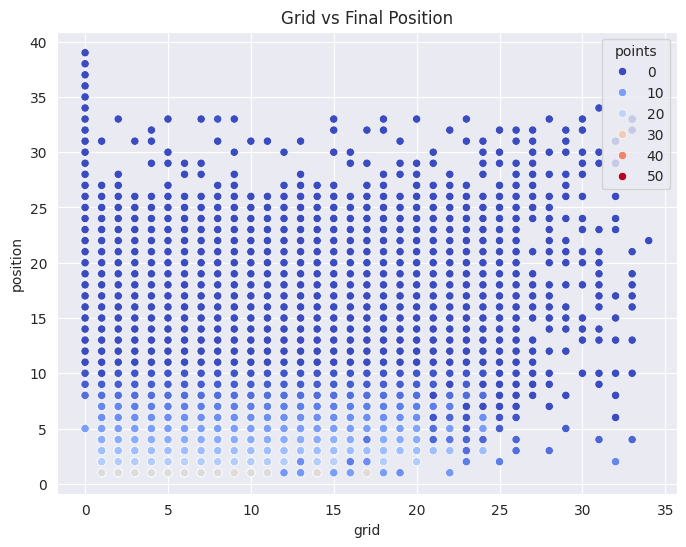

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='grid', y='position', hue='points', palette='coolwarm')
plt.title("Grid vs Final Position")
plt.show()

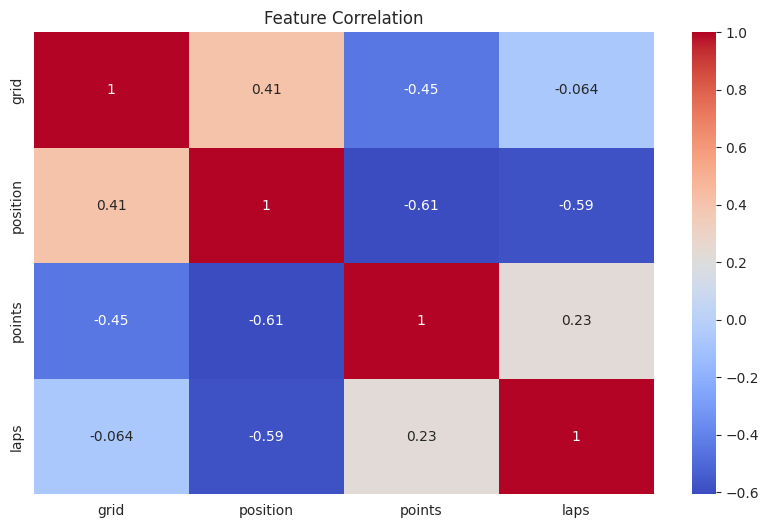

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['grid','position','points','laps']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

## Feature engineering

In [19]:
df['winner'] = (df['position'] == 1).astype(int)

In [20]:
features = ['grid', 'laps', 'constructor_id', 'driver_id']
X = df[features]
y = df['winner']

In [21]:
le_driver = LabelEncoder()
le_constructor = LabelEncoder()

X['driver_id'] = le_driver.fit_transform(X['driver_id'])
X['constructor_id'] = le_constructor.fit_transform(X['constructor_id'])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [24]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9521973785659213
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      4957
           1       0.43      0.23      0.30       231

    accuracy                           0.95      5188
   macro avg       0.70      0.61      0.64      5188
weighted avg       0.94      0.95      0.94      5188



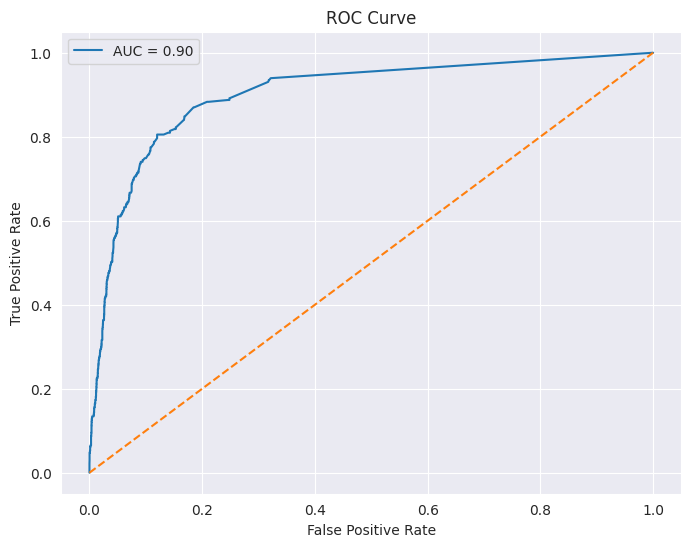

In [25]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [26]:
df['podium'] = df['position'].apply(lambda x: 1 if x <= 3 else 0)

In [27]:
df = df.sort_values(by=['driver_id', 'date'])

In [28]:
df['driver_form'] = df.groupby('driver_id')['position'] \
    .rolling(5, min_periods=1).mean().reset_index(0, drop=True)

In [29]:
df['prev_position'] = df.groupby('driver_id')['position'].shift(1)
df['prev_position'].fillna(df['grid'], inplace=True)

In [30]:
df['constructor_strength'] = df.groupby('constructor_id')['points'] \
    .rolling(10, min_periods=1).mean().reset_index(0, drop=True)

In [31]:
df['win'] = (df['position'] == 1).astype(int)

df['driver_win_rate'] = df.groupby('driver_id')['win'] \
    .expanding().mean().reset_index(level=0, drop=True)

In [32]:
df['grid_advantage'] = df['grid'] - df['driver_form']

In [33]:
features = [
    'grid',
    'laps',
    'driver_form',
    'prev_position',
    'constructor_strength',
    'driver_win_rate',
    'grid_advantage'
]

X = df[features].fillna(0)
y = (df['position'] == 1).astype(int)

In [34]:
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9593292212798766


In [35]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

lgb_model.fit(X_train, y_train)

print("LGB Accuracy:", accuracy_score(y_test, lgb_model.predict(X_test)))

[LightGBM] [Info] Number of positive: 924, number of negative: 19827
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002611 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1171
[LightGBM] [Info] Number of data points in the train set: 20751, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.044528 -> initscore=-3.066088
[LightGBM] [Info] Start training from score -3.066088
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

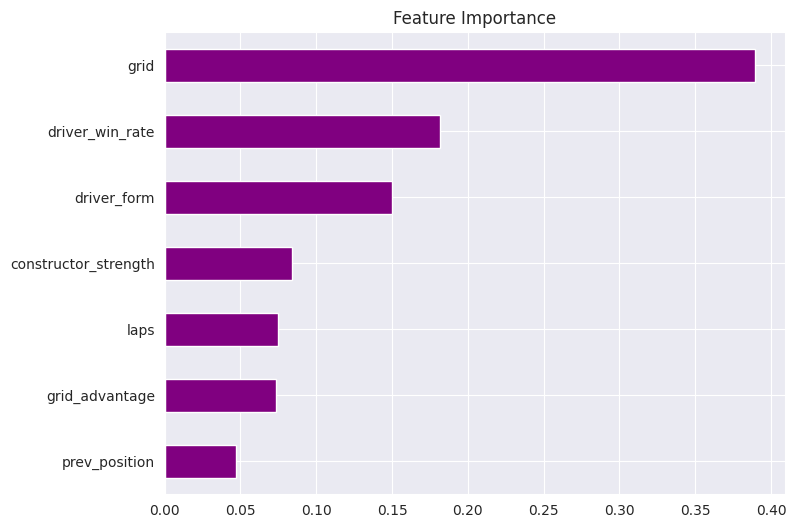

In [36]:
importances = pd.Series(model.feature_importances_, index=features)

importances.sort_values().plot(kind='barh', figsize=(8,6), color='purple')
plt.title("Feature Importance")
plt.show()

In [37]:
import plotly.express as px

top_drivers = df[df['position']==1]['driver_name'].value_counts().head(10).reset_index()
top_drivers.columns = ['Driver','Wins']

fig = px.bar(
    top_drivers,
    x='Wins',
    y='Driver',
    color='Wins',
    title="Top Drivers by Wins",
    color_continuous_scale='Viridis'
)

fig.show()

In [38]:
yearly = df.groupby('season')['points'].sum().reset_index()

fig = px.line(
    yearly,
    x='season',
    y='points',
    title="Total Points Over Time",
    markers=True
)

fig.show()

## Thanl you...pls upvote!!!!!!!!!!
